# ECIP / STM Proposal — Spatial Representativeness of Ground-Based Ozone Lidar

**Goal:** Demonstrate spatial representativeness of TOLNet ozone lidar measurements using STAQS 2023 data.

**Method:** Compute a semivariogram (structure function) of ozone profile similarity as a function of horizontal
separation between TOLNet sites during the STAQS 2023 campaign (July–September 2023).

**Sites (Mid-Atlantic corridor):**
- NASA GSFC TROPOZ — Greenbelt, MD and deployed to NY area
- NASA LaRC — Sherwood Island, CT
- CCNY (NYTOLS) — New York City, NY
- NOAA ESRL/CSL — New Haven, CT area

---

In [1]:
# ============================================================
# CELL 1 — Imports & Setup
# ============================================================
# We suppress warnings to keep the output clean during exploration.
# numpy/pandas/matplotlib are the standard scientific Python stack.
# scipy.optimize.curve_fit is used later to fit the variogram model.
# atmoz is Dr. Roots' custom atmospheric science package (local install).
# AtmoFrame and AtmoDataset are atmoz data wrappers for profile data.

import warnings
warnings.filterwarnings('ignore')

import numpy as np          # Numerical arrays and math
import pandas as pd         # DataFrames — our main tabular data structure
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec   # For multi-panel figure layout
from pathlib import Path    # Cross-platform file path handling
from scipy.optimize import curve_fit    # Nonlinear least-squares fitting

from atmoz.lidar import TOLNET                          # TOLNet API client
from atmoz.dataclasses import AtmoFrame, AtmoDataset    # Atmospheric data wrappers

# Store the notebook's directory so we can save figures relative to it
NOTEBOOK_DIR = Path(__file__).parent if '__file__' in dir() else Path('.').resolve()

# Define a common altitude grid for all profile comparisons.
# All instruments have different native vertical resolutions, so we
# interpolate everything onto this shared 0.5 km grid before comparing.
# Range: 0.5 km to 10 km AGL in 0.5 km steps.
ALT_GRID_KM = np.arange(0.5, 10.5, 0.5)

print('Imports OK')
print(f'Common altitude grid (km): {ALT_GRID_KM}')


Imports OK
Common altitude grid (km): [ 0.5  1.   1.5  2.   2.5  3.   3.5  4.   4.5  5.   5.5  6.   6.5  7.
  7.5  8.   8.5  9.   9.5 10. ]


In [2]:
# ============================================================
# CELL 2 — Discover Available TOLNet Instruments
# ============================================================
# Before loading data, we query the TOLNet API for its reference tables:
#   - instrument_groups : every lidar in the network (ID, name, home location)
#   - products          : data product types (HIRES, CALVAL, CLIM, etc.)
#   - processing_types  : how the data was processed (centrally / in-house)
#
# We need the integer IDs from instrument_groups to request specific sites
# in Cell 3. The key ones for STAQS Mid-Atlantic:
#   id=2  NASA GSFC  (Greenbelt MD home base; also deployed to NY during STAQS)
#   id=4  NASA LaRC  (deployed to Sherwood Island, CT during STAQS)
#   id=9  CCNY       (New York City, stationary)
#   id=5  NOAA CSL   (deployed to New Haven CT area during STAQS)
#
# API_AVAILABLE is used as a guard flag in all downstream cells so the
# notebook degrades gracefully if there is no internet connection.

try:
    tolnet_meta = TOLNET()
    print('=== INSTRUMENT GROUPS ===')
    print(tolnet_meta.instrument_groups.to_string())
    print('\n=== PRODUCT TYPES ===')
    print(tolnet_meta.products.to_string())
    print('\n=== PROCESSING TYPES ===')
    print(tolnet_meta.processing_types.to_string())
    API_AVAILABLE = True
except Exception as e:
    print(f'TOLNet API not reachable: {e}')
    print('Proceeding with known instrument IDs from prior exploration.')
    API_AVAILABLE = False


=== INSTRUMENT GROUPS ===


   instrument_group_name folder_name                                                                                 description  display_order         current_pi                                   doi                                                           citation_url                   home_location  home_latitude  home_longitude
id                                                                                                                                                                                                                                                                                                                                            
1                   ECCC        eccc                                   Environment and Climate Change Canada (mobile instrument)             50  Kevin Strawbridge       10.5067/Lidar/Ozone/TOLNet/ECCC  https://asdc.larc.nasa.gov/project/TOLNet/TOLNet_ECCC_Data_1/citation                     FORT.MACKAY         57.184        -111

           processing_type_name                                                                                  description  display_order public show_on_graph_page
id                                                                                                                                                                   
1   Centrally Processed (GLASS)  Files that have been Centrally Processed using GLASS (Global Lidar Analysis Software Suite)             10      t                  t
2            In-House Processed                              Files that have been processed In House by the Instrument Group             20      t                  t
3                   Unprocessed                                                           Files that have been not processed             30      f                  f


In [3]:
# ============================================================
# CELL 3 — Load STAQS 2023 TOLNet Data
# ============================================================
# We request HIRES (product_type=4) ozone profiles from four Mid-Atlantic
# TOLNet sites that operated during the STAQS campaign (Jul–Sep 2023).
#
# Why HIRES? It provides the highest temporal and vertical resolution,
# which gives us the most profile pairs for the semivariogram analysis.
#
# Note on processing types:
#   - NASA GSFC has Centrally Processed (GLASS) data → most consistent
#   - LaRC, CCNY, NOAA CSL only have In-House Processed for this period
#   - We do NOT filter by processing_type so we capture everything available
#
# The STAQS campaign dates: July–September 2023
# (TEMPO was operational, providing concurrent geostationary coverage)

STAQS_START = '2023-07-01'
STAQS_END   = '2023-09-30'

# Integer IDs from Cell 2 for the four Mid-Atlantic STAQS sites
STAQS_INSTRUMENT_IDS = [2, 4, 9, 5]   # GSFC, LaRC, CCNY, NOAA CSL

tolnet = TOLNET()

try:
    tolnet.import_data(
        min_date=STAQS_START,
        max_date=STAQS_END,
        instrument_group=STAQS_INSTRUMENT_IDS,
        product_type=[4],   # HIRES — highest temporal & vertical resolution
    )
    DATA_LOADED = bool(tolnet.data)
    if not DATA_LOADED:
        print('WARNING: import_data returned empty — API may be unavailable.')
except Exception as e:
    DATA_LOADED = False
    print(f'Data load failed: {e}')

if DATA_LOADED:
    # Each key is a tuple: (instrument_name, processing_type, "lat x lon")
    # The lat/lon reflects where the instrument was actually deployed during STAQS,
    # which may differ from its home base (e.g. GSFC deployed to NY area).
    print(f'\nLoaded {len(tolnet.data)} site/processing-type combinations:')
    print(f'{"Key":70s} {"Dates":5s} {"Profiles"}')
    print('-' * 100)
    for key, date_dict in sorted(tolnet.data.items()):
        total_profiles = sum(len(df) for df in date_dict.values())
        dates = sorted(date_dict.keys())
        print(f'{str(key):70s} {len(dates):4d}  {total_profiles:6d}  '
              f'[{dates[0]} .. {dates[-1]}]')
    if tolnet._errors:
        print(f'\nDownload errors ({len(tolnet._errors)}): {tolnet._errors[:3]}')
else:
    print('No data loaded — downstream cells will be skipped gracefully.')



Loaded 7 site/processing-type combinations:
Key                                                                    Dates Profiles
----------------------------------------------------------------------------------------------------
('CCNY', 'In-House Processed', '40.821x-73.948')                         31    1184  [2023-07-05 .. 2023-09-21]
('NASA GSFC', 'Centrally Processed (GLASS)', '38.98x-76.83')             11     300  [2023-08-31 .. 2023-09-19]
('NASA GSFC', 'Centrally Processed (GLASS)', '40.96x-73.14')             32     762  [2023-07-11 .. 2023-08-16]
('NASA GSFC', 'In-House Processed', '40.964x-73.14')                     37    5328  [2023-07-07 .. 2023-08-16]
('NASA LaRC', 'In-House Processed', '41.1182x-73.3367')                  16    1020  [2023-07-17 .. 2023-08-26]
('NOAA ESRL/CSL', 'In-House Processed', '39.9908x-105.264')              12     500  [2023-08-22 .. 2023-09-28]
('NOAA ESRL/CSL', 'In-House Processed', '41.2592x-72.7311')              36     906  [2023-07-04

In [4]:
# ============================================================
# CELL 4 — Site Metadata and Pairwise Distance Matrix
# ============================================================
# The data keys contain the deployed lat/lon for each instrument.
# We parse these to compute the great-circle distance (km) between
# every pair of sites — this is the "d" axis in the semivariogram.
#
# We filter out any sites outside the Mid-Atlantic bounding box
# (lat 35–45N, lon 80–70W). This removes the NOAA CSL Boulder CO
# home base (~105W) if it appears, keeping only STAQS deployments.
#
# geodesic() from geopy gives the true ellipsoidal distance between
# two (lat, lon) coordinate pairs in kilometers.

from geopy.distance import geodesic

# Mid-Atlantic bounding box — keeps only the STAQS NY/CT/MD deployment area
MID_ATLANTIC_LON_MIN = -80.0
MID_ATLANTIC_LON_MAX = -70.0
MID_ATLANTIC_LAT_MIN =  35.0
MID_ATLANTIC_LAT_MAX =  45.0

if not DATA_LOADED:
    print('Data not loaded — skipping site metadata.')
else:
    site_info = {}
    excluded = []

    # Parse "latxlon" string from each data key into float coordinates
    for key in tolnet.data:
        site_name, proc_type, latlon_str = key
        lat_str, lon_str = latlon_str.split('x')
        lat, lon = float(lat_str), float(lon_str)

        # Drop any sites that are outside the Mid-Atlantic corridor
        if not (MID_ATLANTIC_LAT_MIN <= lat <= MID_ATLANTIC_LAT_MAX and
                MID_ATLANTIC_LON_MIN <= lon <= MID_ATLANTIC_LON_MAX):
            excluded.append((site_name, lat, lon))
            continue

        site_info[key] = {'name': site_name, 'proc': proc_type,
                          'lat': lat, 'lon': lon}

    if excluded:
        print('Sites excluded (outside Mid-Atlantic bounding box):')
        for e in excluded:
            print(f'  {e[0]:20s}  lat={e[1]:.2f}  lon={e[2]:.2f}')

    site_df = pd.DataFrame(site_info).T[['name', 'proc', 'lat', 'lon']]
    site_df['lat'] = site_df['lat'].astype(float)
    site_df['lon'] = site_df['lon'].astype(float)
    print('\nMid-Atlantic sites retained:')
    print(site_df.to_string())

    # Build an n×n distance matrix — one row/column per retained site
    keys = list(site_info.keys())
    n = len(keys)
    dist_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            coord_i = (site_info[keys[i]]['lat'], site_info[keys[i]]['lon'])
            coord_j = (site_info[keys[j]]['lat'], site_info[keys[j]]['lon'])
            dist_matrix[i, j] = geodesic(coord_i, coord_j).kilometers

    short_labels = [
        f"{site_info[k]['name']}\n({site_info[k]['lat']:.1f},{site_info[k]['lon']:.1f})"
        for k in keys
    ]
    dist_df = pd.DataFrame(dist_matrix, index=short_labels, columns=short_labels)

    print('\nPairwise distances (km):')
    print(dist_df.round(1).to_string())

    # Store for use in Cells 6 and beyond
    SITE_KEYS   = keys
    DIST_MATRIX = dist_matrix
    SITE_LABELS = short_labels


Sites excluded (outside Mid-Atlantic bounding box):
  NOAA ESRL/CSL         lat=39.99  lon=-105.26

Mid-Atlantic sites retained:
                                                                     name                         proc      lat      lon
CCNY          In-House Processed          40.821x-73.948             CCNY           In-House Processed  40.8210 -73.9480
NASA GSFC     Centrally Processed (GLASS) 38.98x-76.83          NASA GSFC  Centrally Processed (GLASS)  38.9800 -76.8300
NASA LaRC     In-House Processed          41.1182x-73.3367      NASA LaRC           In-House Processed  41.1182 -73.3367
NASA GSFC     Centrally Processed (GLASS) 40.96x-73.14          NASA GSFC  Centrally Processed (GLASS)  40.9600 -73.1400
              In-House Processed          40.964x-73.14         NASA GSFC           In-House Processed  40.9640 -73.1400
NOAA ESRL/CSL In-House Processed          41.2592x-72.7311  NOAA ESRL/CSL           In-House Processed  41.2592 -72.7311

Pairwise distances (km)


Curtain: CCNY | In-House Processed | 40.821x-73.948 (31 days)


findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


...

findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


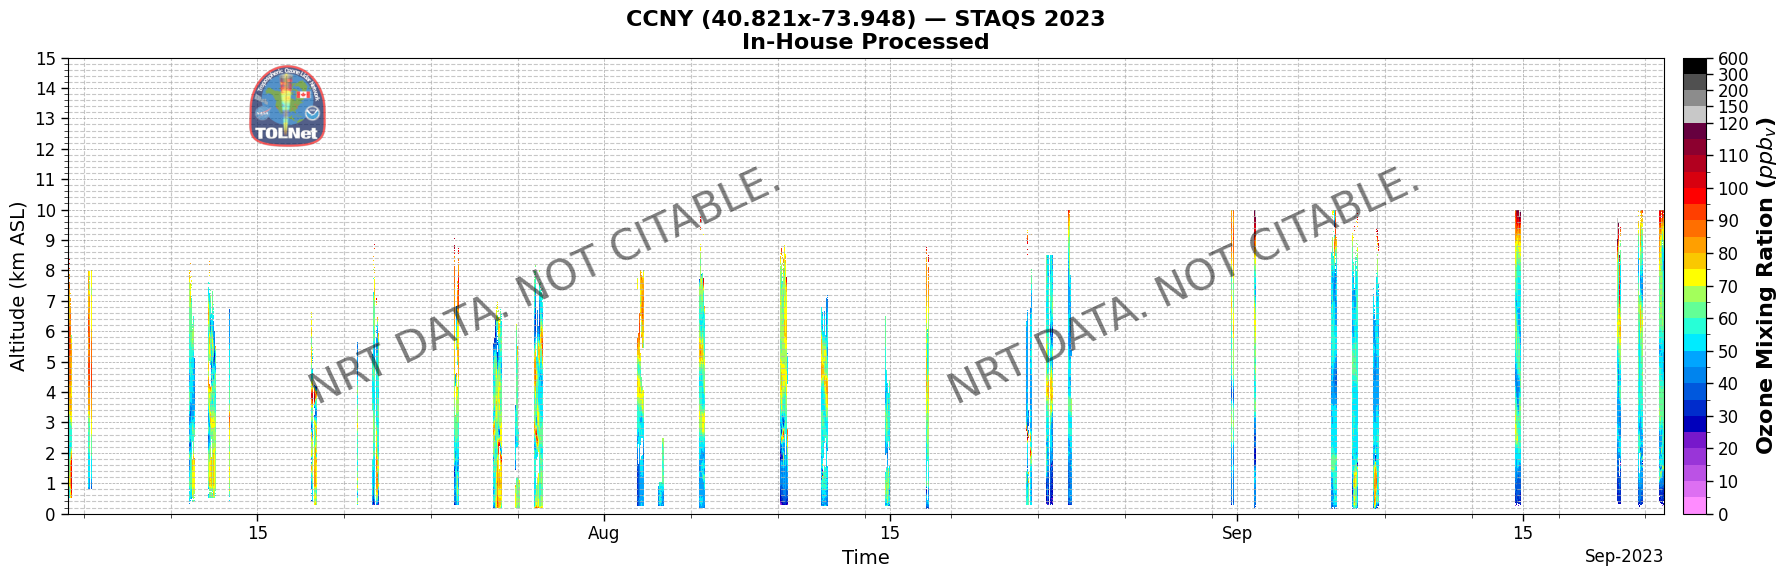

findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


...

findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


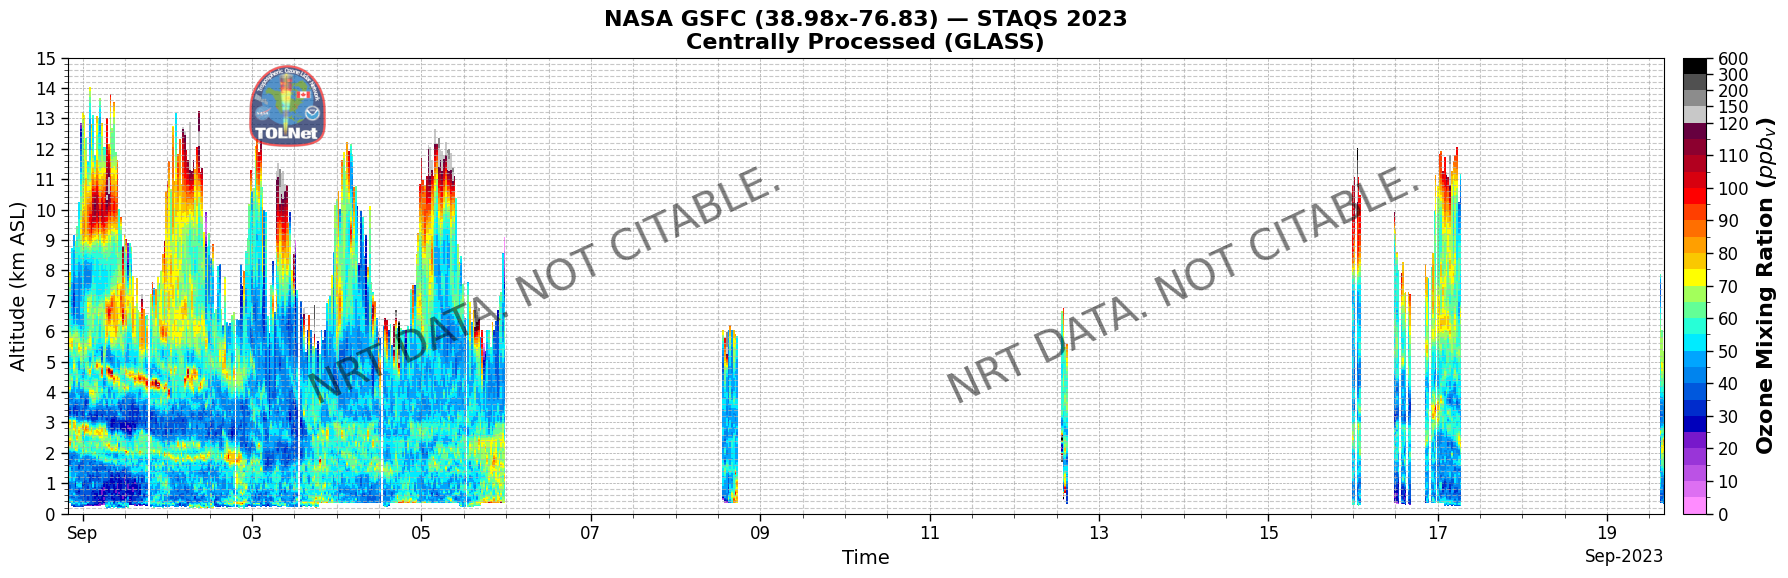

findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.



Curtain: NASA GSFC | Centrally Processed (GLASS) | 40.96x-73.14 (32 days)


findfont: Font family 'Courier New' not found.


...

findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


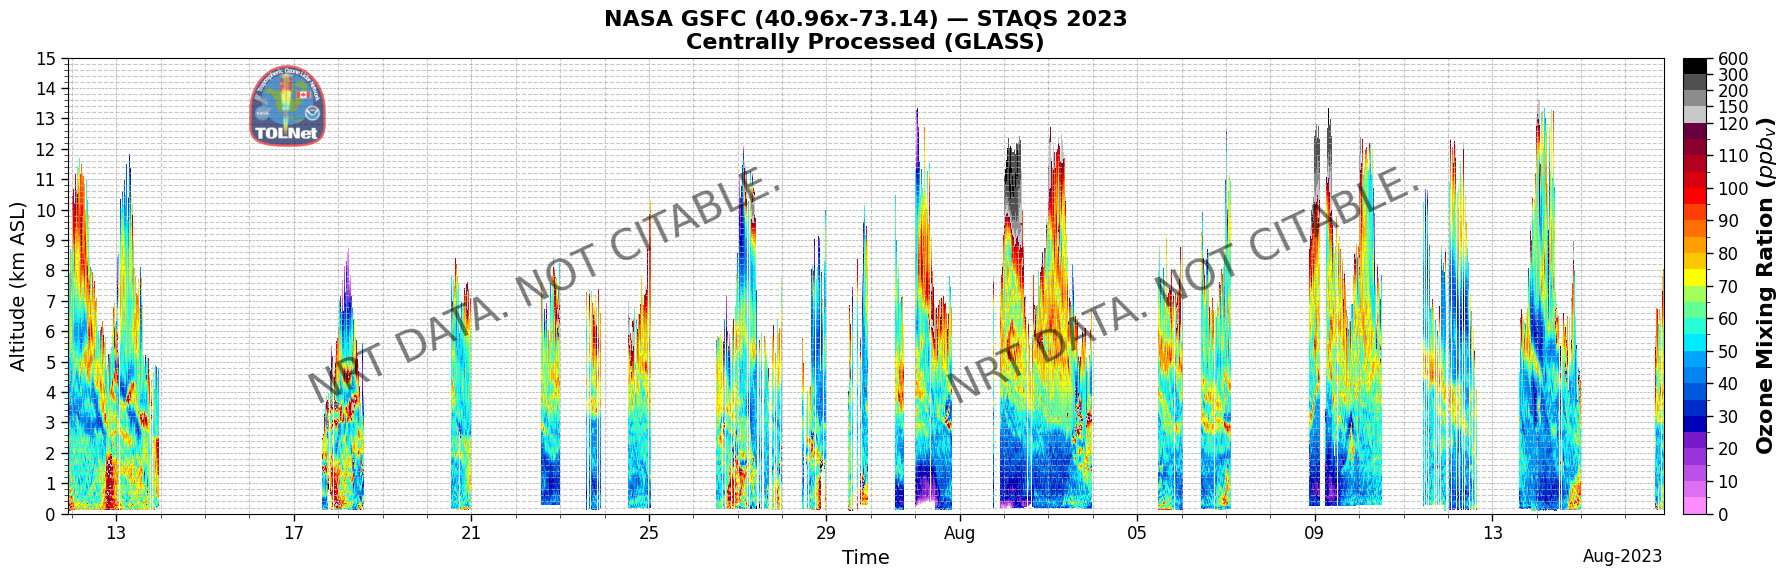


Curtain: NASA GSFC | In-House Processed | 40.964x-73.14 (37 days)


findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


...

findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


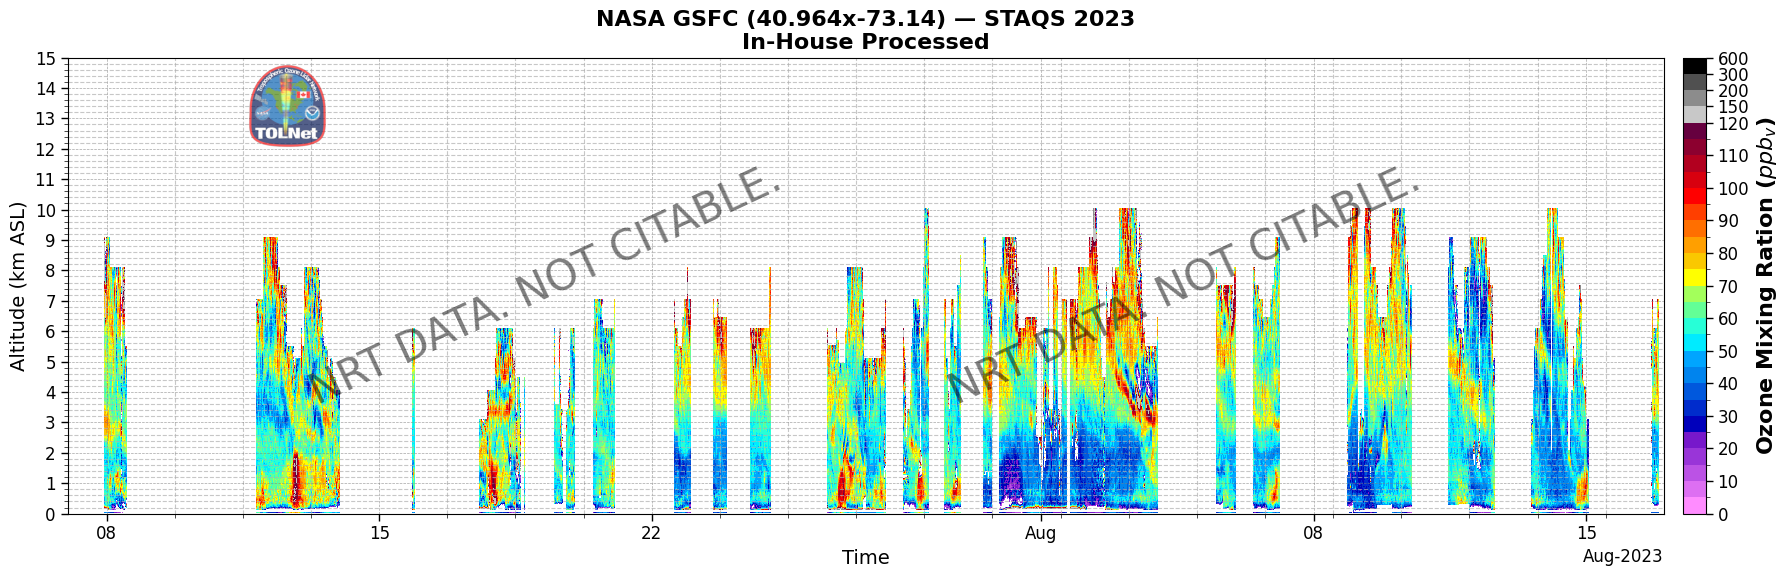


Curtain: NASA LaRC | In-House Processed | 41.1182x-73.3367 (16 days)


findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


...

findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


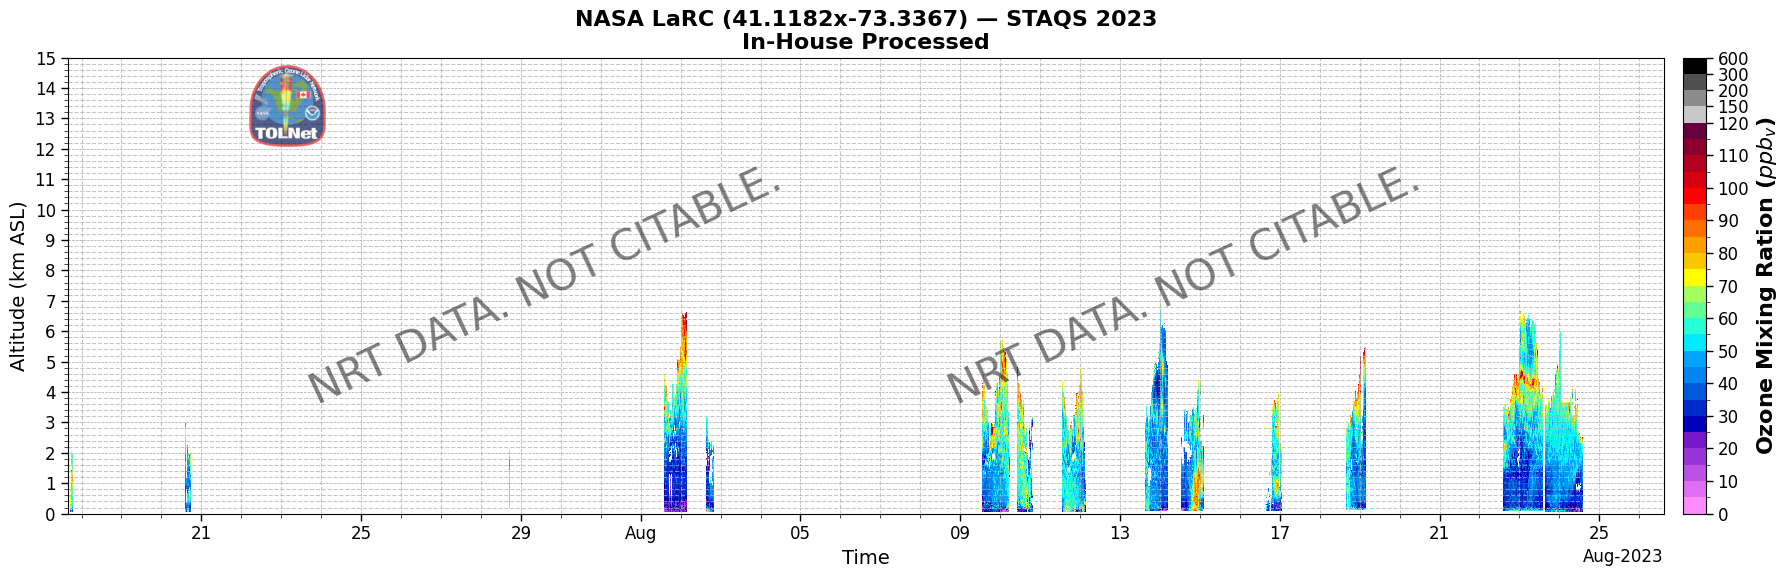


Curtain: NOAA ESRL/CSL | In-House Processed | 39.9908x-105.264 (12 days)


findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


...

findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


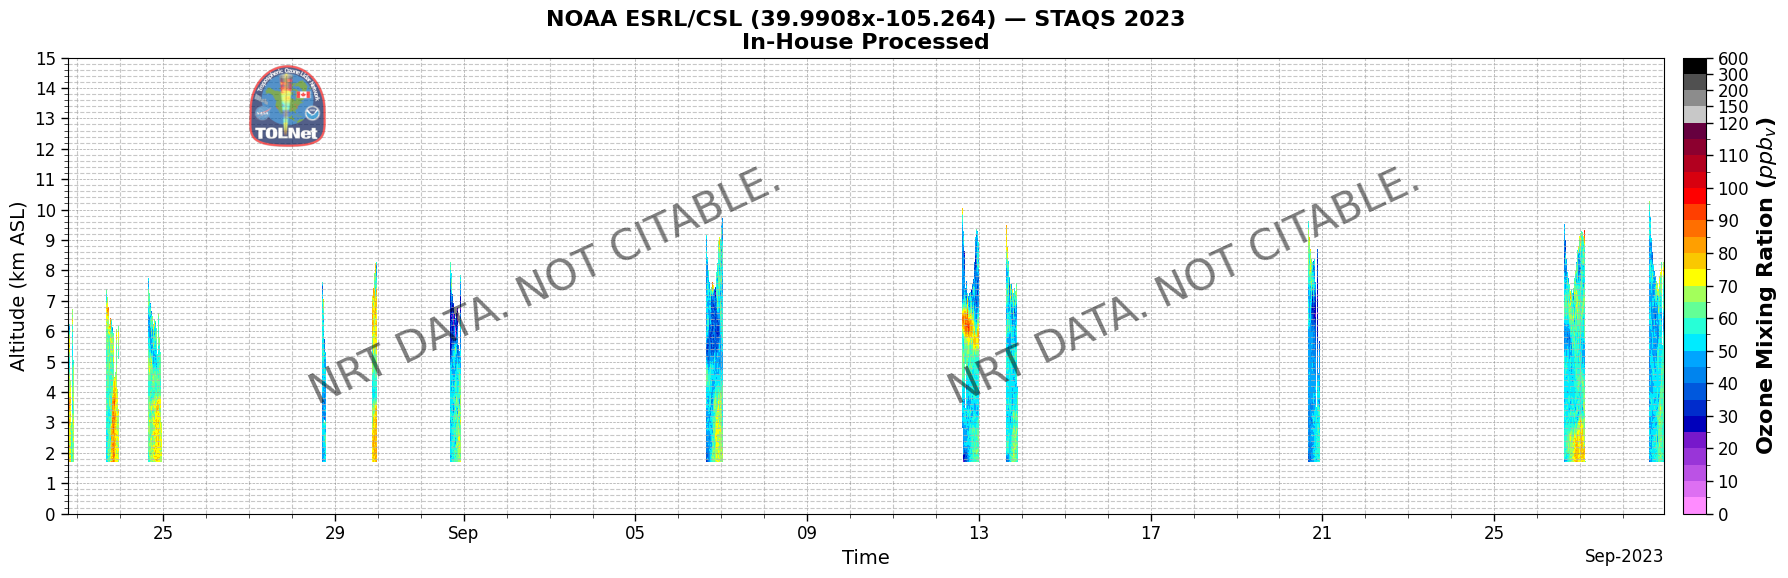


Curtain: NOAA ESRL/CSL | In-House Processed | 41.2592x-72.7311 (36 days)


findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


...

findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


findfont: Font family 'Courier New' not found.


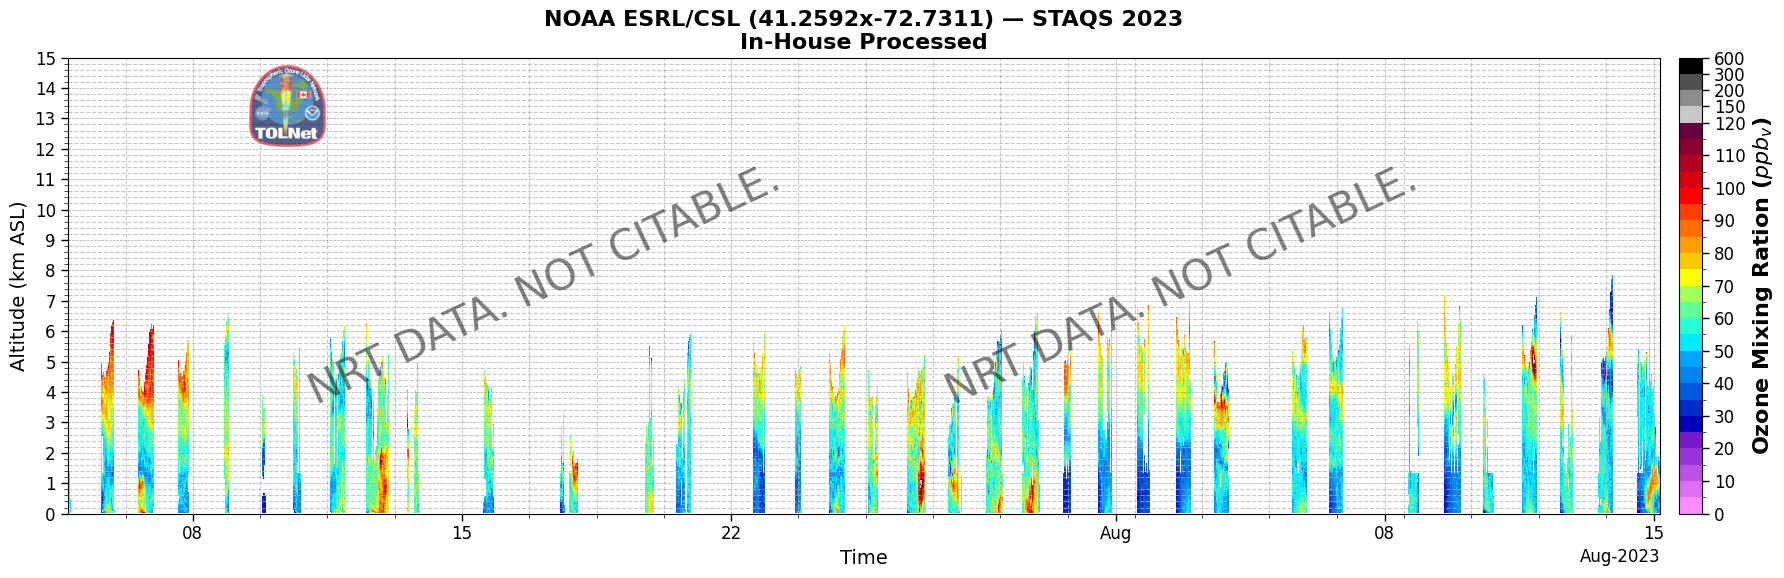

In [5]:
# ============================================================
# CELL 5 — Curtain Plots for Each Site
# ============================================================
# A "curtain plot" shows ozone concentration as a 2D color image:
#   x-axis = time (UTC)
#   y-axis = altitude (km AGL)
#   color  = ozone mixing ratio (ppb)
#
# This is the standard way to visualize lidar data. It lets us
# quickly see the ozone structure over the full campaign period
# and spot any data gaps, outliers, or interesting events.
#
# The atmoz plot_curtain() method handles the pcolormesh rendering.
# We catch errors per-site so one bad file doesn't stop the loop.

if not DATA_LOADED:
    print('Data not loaded — skipping curtain plots.')
else:
    for key in sorted(tolnet.data.keys()):
        site_name, proc_type, latlon = key
        n_dates = len(tolnet.data[key])
        if n_dates == 0:
            continue
        print(f'\nCurtain: {site_name} | {proc_type} | {latlon} ({n_dates} days)')
        try:
            tolnet.plot_curtain(
                data=tolnet.data[key],
                xlims=[STAQS_START, STAQS_END],
                title=f'{site_name} ({latlon}) — STAQS 2023\n{proc_type}',
            )
        except Exception as e:
            print(f'  Curtain plot failed: {e}')


In [6]:
# ============================================================
# CELL 6 — Profile Pair Extraction
# ============================================================
# The core data structure for the semivariogram is a list of
# COINCIDENT PROFILE PAIRS — two ozone profiles measured at the
# same time but at different locations (separated by d km).
#
# Steps:
#   1. Concatenate all daily DataFrames for each site into one
#      continuous time series.
#   2. For every combination of two sites, search for times where
#      both instruments have a profile within ±15 minutes of each other.
#   3. Interpolate both profiles onto the common ALT_GRID_KM.
#   4. Store the pair with its separation distance and UTC hour.
#
# The ±15 min coincidence window is a trade-off:
#   - Too tight → fewer pairs, noisier statistics
#   - Too loose → profiles are no longer truly "simultaneous"
#
# The UTC hour is stored for regime stratification in Cell 9.
# itertools.combinations() generates all unique site pairs (no repeats).

from scipy.interpolate import interp1d
import itertools

def get_profiles(data_dict):
    """
    Merge all per-day DataFrames for one site into a single time-indexed
    DataFrame covering the full campaign. Removes duplicate timestamps.
    """
    frames = [df for df in data_dict.values()]
    if not frames:
        return pd.DataFrame()
    combined = pd.concat(frames)
    combined = combined[~combined.index.duplicated(keep='first')]
    combined.sort_index(inplace=True)
    return combined

def interp_profile(profile_series, alt_grid):
    """
    Interpolate one ozone profile (pandas Series with altitude in km as index)
    onto the shared alt_grid. Returns NaN where the profile doesn't reach.
    Requires at least 3 valid points to interpolate; returns all-NaN otherwise.
    """
    alts = np.array(profile_series.index, dtype=float)
    vals = np.array(profile_series.values, dtype=float)
    valid = np.isfinite(vals) & np.isfinite(alts)
    if valid.sum() < 3:
        return np.full(len(alt_grid), np.nan)
    f = interp1d(alts[valid], vals[valid], kind='linear',
                 bounds_error=False, fill_value=np.nan)
    return f(alt_grid)

COINCIDENCE_WINDOW_MIN = 15   # Maximum time gap (minutes) for a "simultaneous" pair

if not DATA_LOADED:
    print('Data not loaded — skipping profile pair extraction.')
    coincident_pairs = []
else:
    # Build one concatenated time series per site
    all_profiles = {}
    for key in SITE_KEYS:
        df = get_profiles(tolnet.data[key])
        all_profiles[key] = df
        print(f'{str(key)[:65]:65s}: {len(df)} time steps')

    print(f'\nSearching for coincident pairs (±{COINCIDENCE_WINDOW_MIN} min)...')

    coincident_pairs = []

    for (i, key_a), (j, key_b) in itertools.combinations(enumerate(SITE_KEYS), 2):
        df_a = all_profiles[key_a]
        df_b = all_profiles[key_b]

        if df_a.empty or df_b.empty:
            continue

        dist_km = DIST_MATRIX[i, j]   # Pre-computed great-circle distance (km)

        # Ensure both time indexes are UTC-aware for safe comparison
        times_a = pd.DatetimeIndex(df_a.index).tz_convert('UTC')
        times_b = pd.DatetimeIndex(df_b.index).tz_convert('UTC')
        window  = pd.Timedelta(minutes=COINCIDENCE_WINDOW_MIN)

        for t_a in times_a:
            delta   = np.abs(times_b - t_a)
            matches = np.where(delta <= window)[0]
            if len(matches) == 0:
                continue
            # If multiple B times fall in the window, take the closest one
            best_idx = matches[np.argmin(delta[matches])]
            t_b = times_b[best_idx]

            # Retrieve the profile rows and interpolate onto the common grid
            iloc_a   = df_a.index.get_indexer([t_a], method='nearest')[0]
            iloc_b   = df_b.index.get_indexer([t_b], method='nearest')[0]
            prof_a   = interp_profile(df_a.iloc[iloc_a], ALT_GRID_KM)
            prof_b   = interp_profile(df_b.iloc[iloc_b], ALT_GRID_KM)

            coincident_pairs.append({
                'key_a':    key_a,
                'key_b':    key_b,
                'time_a':   t_a,
                'time_b':   t_b,
                'dist_km':  dist_km,         # Separation distance in km
                'prof_a':   prof_a,           # Interpolated ozone profile (ppb), site A
                'prof_b':   prof_b,           # Interpolated ozone profile (ppb), site B
                'hour_utc': t_a.hour + t_a.minute / 60.0,  # Decimal UTC hour for regime tagging
            })

    print(f'Total coincident profile pairs found: {len(coincident_pairs)}')
    if coincident_pairs:
        dist_vals = [p['dist_km'] for p in coincident_pairs]
        print(f'Separation distances (km): {sorted(set(round(d, 1) for d in dist_vals))}')


('CCNY', 'In-House Processed', '40.821x-73.948')                 : 1184 time steps
('NASA GSFC', 'Centrally Processed (GLASS)', '38.98x-76.83')     : 300 time steps
('NASA LaRC', 'In-House Processed', '41.1182x-73.3367')          : 1020 time steps
('NASA GSFC', 'Centrally Processed (GLASS)', '40.96x-73.14')     : 762 time steps
('NASA GSFC', 'In-House Processed', '40.964x-73.14')             : 5328 time steps
('NOAA ESRL/CSL', 'In-House Processed', '41.2592x-72.7311')      : 906 time steps

Searching for coincident pairs (±15 min)...


Total coincident profile pairs found: 6929
Separation distances (km): [np.float64(0.4), np.float64(23.8), np.float64(24.1), np.float64(47.5), np.float64(47.8), np.float64(53.2), np.float64(61.1), np.float64(69.8), np.float64(69.9), np.float64(113.3), np.float64(320.2)]


Total valid (pair, alt) observations: 54968
Unique separation distances: [np.float64(0.4), np.float64(23.8), np.float64(24.1), np.float64(47.5), np.float64(47.8), np.float64(53.2), np.float64(61.1), np.float64(69.8), np.float64(69.9), np.float64(113.3), np.float64(320.2)]

Semivariogram table (first 20 rows):
 dist_km  alt_km       mean  n_pairs      gamma
0.444213     0.5 163.277008      748  81.638504
0.444213     1.0 209.204616      752 104.602308
0.444213     1.5 266.695709      754 133.347854
0.444213     2.0 144.241468      757  72.120734
0.444213     2.5 155.814657      752  77.907329
0.444213     3.0 130.421958      750  65.210979
0.444213     3.5 308.379784      738 154.189892
0.444213     4.0 136.008006      733  68.004003
0.444213     4.5 195.438224      700  97.719112
0.444213     5.0 137.364684      679  68.682342
0.444213     5.5 178.158888      638  89.079444
0.444213     6.0 271.321127      573 135.660564
0.444213     6.5 265.276120      413 132.638060
0.444213     7.0 

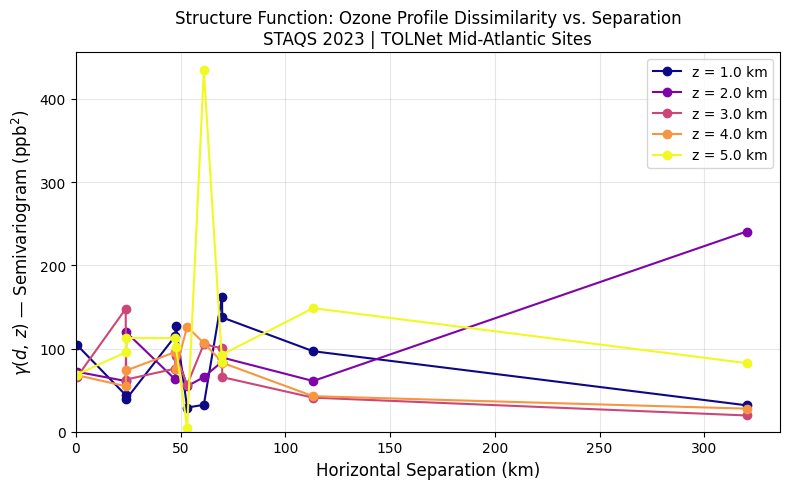

In [7]:
# ============================================================
# CELL 7 — Structure Function (Semivariogram)
# ============================================================
# The semivariogram γ(d, z) measures how "different" two ozone profiles
# are, as a function of:
#   d = horizontal separation between the two sites (km)
#   z = altitude (km AGL)
#
# Formula:
#   γ(d, z) = 0.5 × mean( [X_a(z) - X_b(z)]² )
#
# where X_a and X_b are simultaneous ozone profiles at two sites
# separated by d km. The 0.5 factor is the standard geostatistical
# convention that makes γ equal to half the variance of the differences.
#
# Interpretation:
#   γ ≈ 0  → profiles are nearly identical (high representativeness)
#   γ large → profiles have diverged (low representativeness)
#
# At short distances, γ should be small (nearby profiles look alike).
# As d increases, γ should rise and eventually plateau at the "sill"
# (the point where the profiles are statistically independent).
# The distance where γ reaches the sill is the representativeness length
# scale L_rep — the key deliverable of this proposal.

if not DATA_LOADED or not coincident_pairs:
    print('No coincident pairs available — skipping semivariogram.')
    gamma_table = pd.DataFrame()
else:
    # Unpack each pair into one row per (pair, altitude) observation
    records = []
    for pair in coincident_pairs:
        diff    = pair['prof_a'] - pair['prof_b']   # Profile difference at each altitude
        sq_diff = diff ** 2                           # Squared difference

        for k, alt in enumerate(ALT_GRID_KM):
            if np.isfinite(sq_diff[k]):
                records.append({
                    'pair':     f"{pair['key_a'][0]}|{pair['key_b'][0]}",
                    'dist_km':  pair['dist_km'],
                    'alt_km':   alt,
                    'sq_diff':  sq_diff[k],
                    'hour_utc': pair['hour_utc'],
                })

    df_pairs = pd.DataFrame(records)
    print(f'Total valid (pair, alt) observations: {len(df_pairs)}')
    print(f'Unique separation distances: {sorted(df_pairs["dist_km"].unique().round(1))}')

    # Average the squared differences within each (separation distance, altitude) bin
    # to get one γ value per bin — this is the empirical semivariogram
    gamma_table = (
        df_pairs.groupby(['dist_km', 'alt_km'])['sq_diff']
        .agg(['mean', 'count'])
        .reset_index()
    )
    gamma_table['gamma']   = 0.5 * gamma_table['mean']
    gamma_table.rename(columns={'count': 'n_pairs'}, inplace=True)

    print('\nSemivariogram table (first 20 rows):')
    print(gamma_table.head(20).to_string(index=False))

    # Plot γ vs d for a selection of altitude layers
    # Each line shows how ozone dissimilarity grows with distance at that height
    alt_layers = [1.0, 2.0, 3.0, 4.0, 5.0]
    alt_layers = [a for a in alt_layers if a in gamma_table['alt_km'].values]

    if alt_layers:
        fig, ax = plt.subplots(figsize=(8, 5))
        cmap   = plt.get_cmap('plasma')
        colors = [cmap(i / max(len(alt_layers) - 1, 1)) for i in range(len(alt_layers))]

        for alt, color in zip(alt_layers, colors):
            sub = gamma_table[gamma_table['alt_km'] == alt].sort_values('dist_km')
            if sub.empty:
                continue
            ax.plot(sub['dist_km'], sub['gamma'], 'o-', color=color,
                    label=f'z = {alt:.1f} km', linewidth=1.5, markersize=6)

        ax.set_xlabel('Horizontal Separation (km)', fontsize=12)
        ax.set_ylabel(r'$\gamma(d,\,z)$ — Semivariogram (ppb$^2$)', fontsize=12)
        ax.set_title('Structure Function: Ozone Profile Dissimilarity vs. Separation\n'
                     'STAQS 2023 | TOLNet Mid-Atlantic Sites', fontsize=12)
        ax.legend(fontsize=10, framealpha=0.8)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(left=0)
        ax.set_ylim(bottom=0)
        plt.tight_layout()
        plt.show()
    else:
        print('No matching altitude layers found in gamma_table — check ALT_GRID_KM.')


In [ ]:
# ============================================================
# CELL 8 — Fit Exponential Variogram Model → L_rep
# ============================================================
# We fit the standard exponential variogram model to the empirical
# γ(d) curve at each altitude:
#
#   γ(d) = nugget + sill × (1 − exp(−d / range_L))
#
# Parameters:
#   nugget  : γ at d=0 (represents measurement noise + sub-grid variability)
#   sill    : the variance plateau (profiles become fully independent beyond here)
#   range_L : the e-folding decay length — our representativeness distance L_rep
#
# We flag fits where range_L hits the upper bound (1.5× max separation).
# This means the network aperture (~350 km) is too small to observe the sill
# — the profiles are still correlated even at the largest separations.
# These "ceiling" fits are physically meaningful (high representativeness)
# but statistically unconstrained for the exact range value.

def exponential_variogram(d, nugget, sill, range_L):
    """
    Standard exponential variogram model.
    d       : separation distance (km)
    nugget  : y-intercept (noise floor)
    sill    : asymptotic plateau value
    range_L : e-folding length scale (km) — the representativeness distance
    """
    return nugget + sill * (1.0 - np.exp(-d / range_L))

if gamma_table.empty:
    print('No gamma data — skipping variogram fitting.')
    fit_results = pd.DataFrame()
else:
    d_max_data = gamma_table['dist_km'].max()   # Largest separation in the dataset

    fit_records  = []
    unique_alts  = sorted(gamma_table['alt_km'].unique())

    for alt in unique_alts:
        sub = gamma_table[gamma_table['alt_km'] == alt].sort_values('dist_km')
        d   = sub['dist_km'].values
        g   = sub['gamma'].values

        valid_mask = np.isfinite(g)
        n_pts      = valid_mask.sum()
        if n_pts < 3:          # Need at least 3 points to fit 3 parameters
            continue

        d_fit = d[valid_mask]
        g_fit = g[valid_mask]

        try:
            g_max       = max(g_fit.max(), 1.0)
            range_upper = d_max_data * 1.5    # Upper bound: 1.5× network aperture

            # Initial parameter guesses and bounds for the optimizer
            p0     = [g_fit.min() * 0.5, g_max * 0.5, d_max_data / 3.0]
            bounds = ([0, 0, 1.0], [g_max * 5, g_max * 10, range_upper])

            popt, pcov = curve_fit(
                exponential_variogram, d_fit, g_fit,
                p0=p0, bounds=bounds, maxfev=10000
            )
            nugget, sill, range_L = popt
            perr = np.sqrt(np.diag(pcov))   # 1-sigma parameter uncertainties

            # Flag if range hit the ceiling — fit is valid but L_rep is a lower bound
            at_ceiling = range_L >= range_upper * 0.95

            fit_records.append({
                'alt_km':        alt,
                'nugget':        nugget,
                'sill':          sill,
                'range_L_km':    range_L,
                'range_L_err_km': perr[2],
                'n_dist_pts':    n_pts,
                'at_ceiling':    at_ceiling,
            })
        except Exception:
            # Fit failed to converge — record as ceiling
            fit_records.append({
                'alt_km': alt, 'nugget': np.nan, 'sill': np.nan,
                'range_L_km': np.nan, 'range_L_err_km': np.nan,
                'n_dist_pts': n_pts, 'at_ceiling': True,
            })

    fit_results = pd.DataFrame(fit_records)
    good    = fit_results[~fit_results['at_ceiling'] & fit_results['range_L_km'].notna()]
    ceiling = fit_results[fit_results['at_ceiling']]

    print(f'Variogram fits: {len(good)} well-constrained, {len(ceiling)} hit range ceiling')
    print('\nWell-constrained fits (L_rep in km):')
    print(good[['alt_km', 'nugget', 'sill', 'range_L_km', 'range_L_err_km', 'n_dist_pts']].round(1).to_string(index=False))
    print('\nCeiling fits (range = max separation; L_rep is a lower bound at these altitudes):')
    print(ceiling[['alt_km', 'nugget', 'range_L_km', 'n_dist_pts']].round(1).to_string(index=False))

    # Plot L_rep vs altitude for the well-constrained fits only
    if not good.empty:
        fig, ax = plt.subplots(figsize=(5, 7))
        xerr = good['range_L_err_km'].clip(upper=good['range_L_km'] * 0.9).values
        ax.errorbar(
            good['range_L_km'], good['alt_km'],
            xerr=xerr,
            fmt='o-', color='steelblue', capsize=4, linewidth=1.5, markersize=7,
            label=r'$L_{rep}$ (±1$\sigma$)'
        )
        ax.set_xlabel(r'$L_{rep}$ — Representativeness Distance (km)', fontsize=12)
        ax.set_ylabel('Altitude (km AGL)', fontsize=12)
        ax.set_title('Ozone Lidar Representativeness Scale\n'
                     'STAQS 2023 | Exponential Variogram Fit', fontsize=12)
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(left=0)
        plt.tight_layout()
        plt.show()
    else:
        print('No well-constrained fits — network aperture may be too small for a '
              'reliable range estimate at most altitudes.')


Pair counts by regime:


regime
Daytime (10-16 UTC)      11124
Nighttime (22-04 UTC)    10857
Transition               32987


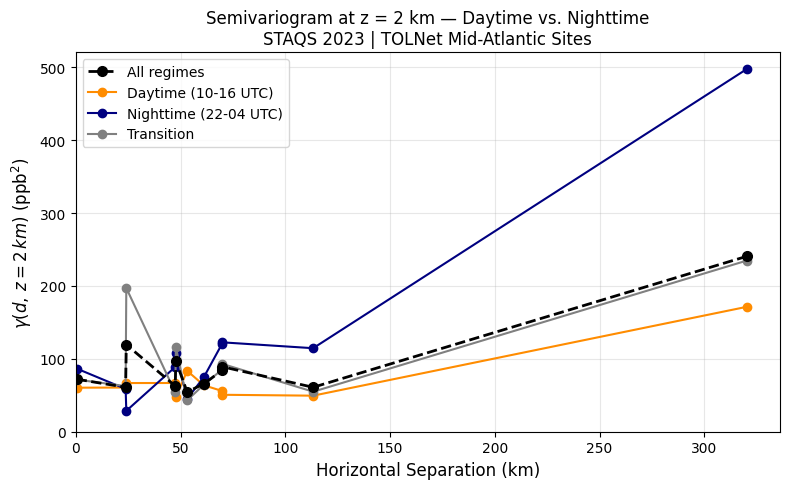

In [9]:
# ============================================================
# CELL 9 — Regime Stratification (Daytime vs. Nighttime)
# ============================================================
# One of the core scientific claims of the proposal is that the
# representativeness distance L_rep depends on "atmospheric regime" —
# i.e., the boundary-layer depth, stability, and transport conditions.
#
# As a simple, data-driven proxy for regime, we split by TIME OF DAY:
#
#   Daytime  (10:00–16:00 UTC): boundary layer is well-mixed and deep
#   Nighttime (22:00–04:00 UTC): boundary layer is shallow and stable
#   Transition: morning/evening — excluded from clean regime comparisons
#
# If daytime and nighttime semivariograms differ, it demonstrates that
# the representativeness distance is regime-dependent — the central
# scientific hypothesis of the proposal.
#
# Note: UTC 10–16 ≈ Eastern 06–12 (morning peak), UTC 22–04 ≈ Eastern 18–00
# (evening/overnight). Adjust if needed for local solar noon (~17:00 UTC at -75W).

def classify_regime(hour_utc):
    """Assign a simple BL-proxy regime based on UTC hour."""
    if 10.0 <= hour_utc < 16.0:
        return 'Daytime (10-16 UTC)'
    elif hour_utc >= 22.0 or hour_utc < 4.0:
        return 'Nighttime (22-04 UTC)'
    return 'Transition'

if not DATA_LOADED or not coincident_pairs or df_pairs.empty:
    print('No pair data — skipping regime stratification.')
else:
    # Tag each (pair, altitude) observation with its regime
    df_pairs['regime'] = df_pairs['hour_utc'].apply(classify_regime)
    print('Pair counts by regime:')
    print(df_pairs.groupby('regime').size().to_string())

    # Compute the semivariogram separately for each regime
    gamma_regimes = {}
    for regime_name, group in df_pairs.groupby('regime'):
        gam = (
            group.groupby(['dist_km', 'alt_km'])['sq_diff']
            .agg(['mean', 'count'])
            .reset_index()
        )
        gam['gamma'] = 0.5 * gam['mean']
        gam.rename(columns={'count': 'n_pairs'}, inplace=True)
        gamma_regimes[regime_name] = gam

    # Compare regimes at 2 km altitude — the BL is most active here
    ALT_PLOT = 2.0
    regime_colors = {
        'Daytime (10-16 UTC)':  'darkorange',
        'Nighttime (22-04 UTC)': 'navy',
        'Transition':            'gray',
    }

    fig, ax = plt.subplots(figsize=(8, 5))

    # Overlay the all-regime curve as a baseline reference
    overall_sub = gamma_table[gamma_table['alt_km'] == ALT_PLOT].sort_values('dist_km')
    if not overall_sub.empty:
        ax.plot(overall_sub['dist_km'], overall_sub['gamma'], 'k--o',
                label='All regimes', linewidth=2, markersize=7, zorder=5)

    for regime_name, gam_df in gamma_regimes.items():
        sub   = gam_df[gam_df['alt_km'] == ALT_PLOT].sort_values('dist_km')
        if sub.empty:
            continue
        color = regime_colors.get(regime_name, 'gray')
        ax.plot(sub['dist_km'], sub['gamma'], 'o-', color=color,
                label=regime_name, linewidth=1.5, markersize=6)

    ax.set_xlabel('Horizontal Separation (km)', fontsize=12)
    ax.set_ylabel(r'$\gamma(d,\,z=2\,km)$ (ppb$^2$)', fontsize=12)
    ax.set_title(f'Semivariogram at z = {ALT_PLOT:.0f} km — Daytime vs. Nighttime\n'
                 'STAQS 2023 | TOLNet Mid-Atlantic Sites', fontsize=12)
    ax.legend(fontsize=10, framealpha=0.8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    plt.show()


In [ ]:
# ============================================================
# CELL 10 — Summary Figure (Proposal Feasibility Figure)
# ============================================================
# This is the "money figure" for the ECIP proposal — the two-panel
# plot that demonstrates the analysis is feasible and the science
# is real. It would appear in the S/T/M section as evidence that
# (a) the semivariogram approach works on real data, and
# (b) the representativeness length scale is measurable.
#
# Panel (a): γ(d) at z = 2 km with the fitted exponential model overlaid.
#   Shows the raw empirical decay and the fitted curve.
#   The fitted L_rep value appears in the legend.
#
# Panel (b): L_rep vs. altitude profile.
#   Shows how the representativeness distance varies with height.
#   Only well-constrained fits are plotted; ceiling fits (where the
#   network aperture is too small to resolve the sill) are noted in text.
#
# The figure is saved as a PNG so it can be dropped directly into the
# proposal document or shared with collaborators.

if gamma_table.empty or fit_results.empty:
    print('Insufficient data for summary figure.')
else:
    ALT_PANEL1 = 2.0   # Altitude for the left panel (km) — focus on the BL

    # Well-constrained fits only for the right panel
    good_fits = fit_results[~fit_results['at_ceiling'] & fit_results['range_L_km'].notna()]

    fig = plt.figure(figsize=(12, 6))
    gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.38)
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])

    # ---- Panel (a): Semivariogram at 2 km with model fit ---- #
    sub1 = gamma_table[gamma_table['alt_km'] == ALT_PANEL1].sort_values('dist_km')

    if not sub1.empty:
        # Scatter the observed γ values
        ax1.scatter(sub1['dist_km'], sub1['gamma'],
                    s=80, zorder=4, color='#1f77b4', label='Observed $\\gamma$')

        # Overlay the smooth exponential model fit
        fit_row = fit_results[fit_results['alt_km'] == ALT_PANEL1]
        if not fit_row.empty and np.isfinite(fit_row.iloc[0]['range_L_km']):
            pfit     = fit_row.iloc[0]
            d_smooth = np.linspace(0, sub1['dist_km'].max() * 1.1, 300)
            g_smooth = exponential_variogram(d_smooth,
                                             pfit['nugget'], pfit['sill'], pfit['range_L_km'])
            label_str = (f"Exp. variogram\n$L_{{rep}}$ = {pfit['range_L_km']:.0f} km"
                         if not pfit['at_ceiling']
                         else "Exp. variogram\n(range unconstrained)")
            ax1.plot(d_smooth, g_smooth, 'r-', linewidth=2, label=label_str)

        ax1.set_xlabel('Horizontal Separation (km)', fontsize=12)
        ax1.set_ylabel(r'$\gamma(d,\;z{=}2\,\mathrm{km})\ \mathrm{(ppb^2)}$', fontsize=12)
        ax1.set_title(f'(a) Semivariogram at $z$ = {ALT_PANEL1:.0f} km\n'
                      'STAQS 2023 — All Sites, All Regimes', fontsize=11)
        ax1.legend(fontsize=10, framealpha=0.9)
        ax1.grid(True, alpha=0.3)
        ax1.set_xlim(left=0)
        ax1.set_ylim(bottom=0)

    # ---- Panel (b): L_rep vs altitude ---- #
    if not good_fits.empty:
        xerr = good_fits['range_L_err_km'].clip(upper=good_fits['range_L_km'] * 0.9).values
        ax2.errorbar(
            good_fits['range_L_km'], good_fits['alt_km'],
            xerr=xerr,
            fmt='o-', color='steelblue', capsize=4,
            linewidth=1.5, markersize=7, label=r'$L_{rep}$ (±1$\sigma$)'
        )
        # Reference line — 100 km is a typical "representative" threshold in the literature
        ax2.axvline(x=100, color='gray', linestyle='--', alpha=0.6, label='100 km reference')
        ax2.set_xlabel(r'$L_{rep}$ — Representativeness Distance (km)', fontsize=12)
        ax2.set_ylabel('Altitude (km AGL)', fontsize=12)
        ax2.set_title('(b) Representativeness Length Scale\n'
                      'STAQS 2023 — Exponential Variogram', fontsize=11)
        ax2.legend(fontsize=10, framealpha=0.9)
        ax2.grid(True, alpha=0.3)
        ax2.set_xlim(left=0)
        ax2.set_ylim(0, 10)
        ax2.text(0.97, 0.03,
                 f'n = {len(good_fits)} altitude bins\n(well-constrained fits)',
                 transform=ax2.transAxes, ha='right', va='bottom',
                 fontsize=9, color='steelblue',
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))
    else:
        # If no fits are constrained, explain why in the panel itself
        ax2.text(0.5, 0.5,
                 'Insufficient network aperture\nfor constrained L_rep fits\n'
                 '(all altitudes: range > max separation)',
                 transform=ax2.transAxes, ha='center', va='center',
                 fontsize=10, color='gray', multialignment='center')
        ax2.set_xlabel(r'$L_{rep}$ (km)', fontsize=12)
        ax2.set_ylabel('Altitude (km AGL)', fontsize=12)
        ax2.set_title('(b) Representativeness Length Scale\n'
                      'STAQS 2023 — Exponential Variogram', fontsize=11)

    fig.suptitle(
        'Spatial Representativeness of Ground-Based Ozone Lidar — STAQS 2023\n'
        'TOLNet Mid-Atlantic Corridor  |  ECIP Proposal Feasibility Figure',
        fontsize=12, fontweight='bold', y=1.02
    )
    plt.tight_layout()
    # Save the figure alongside the notebook for easy access
    plt.savefig(NOTEBOOK_DIR / 'ecip_summary_figure.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Summary figure saved to ecip_summary_figure.png')
